iter 0 loss 3.3595774173736572
iter 50 loss 4.19364595413208
iter 100 loss 4.151318550109863
iter 150 loss 4.103536128997803
iter 200 loss 4.043880939483643
iter 250 loss 3.965801954269409


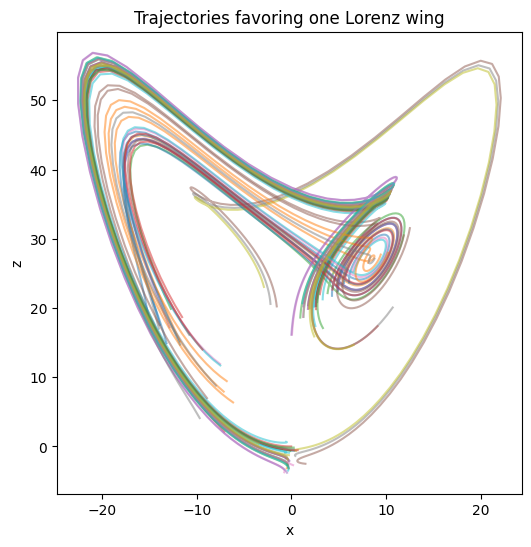

In [2]:


import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

# -----------------------------
# Simple Lorenz one-step model
# -----------------------------
class LorenzStep(nn.Module):

    def __init__(self, dt=0.01):
        super().__init__()

        self.sigma = 10.0
        self.rho = 28.0
        self.beta = 8.0/3.0
        self.dt = dt

    def forward(self, x):

        X = x[:,0]
        Y = x[:,1]
        Z = x[:,2]

        dx = self.sigma*(Y - X)
        dy = X*(self.rho - Z) - Y
        dz = X*Y - self.beta*Z

        X = X + self.dt*dx
        Y = Y + self.dt*dy
        Z = Z + self.dt*dz

        return torch.stack([X,Y,Z],dim=1)


model = LorenzStep()

# -----------------------------------
# Multiple initial conditions (NIO)
# -----------------------------------

n_points = 50

x0 = torch.randn(n_points,3,requires_grad=True)

optimizer = optim.Adam([x0], lr=0.05)

T = 100
iters = 300


# -----------------------------------
# Optimization
# -----------------------------------

for i in range(iters):

    x = x0
    traj = []

    for t in range(T):

        x = model(x)
        traj.append(x)

    traj = torch.stack(traj)      # shape (T, N, 3)

    # encourage staying on positive wing (x > 0)
    ## loss = torch.relu(-traj[:,:,0]).mean()
    
    
    target_sign = 1   # +1 right wing, -1 left wing
    loss        = torch.relu(-target_sign * traj[:,:,0]).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 50 == 0:
        print("iter",i,"loss",loss.item())


# -----------------------------------
# Visualize trajectories
# -----------------------------------

traj_np = traj.detach().numpy()

plt.figure(figsize=(6,6))

for i in range(n_points):
    plt.plot(traj_np[:,i,0],traj_np[:,i,2],alpha=0.5)

plt.xlabel("x")
plt.ylabel("z")
plt.title("Trajectories favoring one Lorenz wing")

plt.show()






iter 0 loss 3.4167938232421875
iter 50 loss 4.230801105499268
iter 100 loss 4.1866559982299805
iter 150 loss 4.182676792144775
iter 200 loss 4.128374099731445
iter 250 loss 4.058876037597656


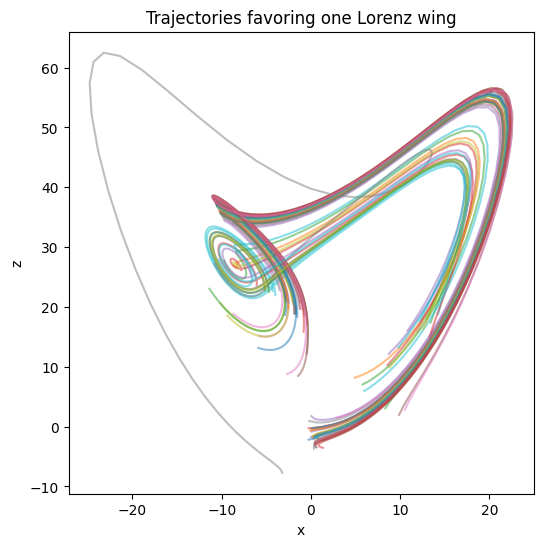

In [3]:


import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

# -----------------------------
# Simple Lorenz one-step model
# -----------------------------
class LorenzStep(nn.Module):

    def __init__(self, dt=0.01):
        super().__init__()

        self.sigma = 10.0
        self.rho = 28.0
        self.beta = 8.0/3.0
        self.dt = dt

    def forward(self, x):

        X = x[:,0]
        Y = x[:,1]
        Z = x[:,2]

        dx = self.sigma*(Y - X)
        dy = X*(self.rho - Z) - Y
        dz = X*Y - self.beta*Z

        X = X + self.dt*dx
        Y = Y + self.dt*dy
        Z = Z + self.dt*dz

        return torch.stack([X,Y,Z],dim=1)


model = LorenzStep()

# -----------------------------------
# Multiple initial conditions (NIO)
# -----------------------------------

n_points = 50

x0 = torch.randn(n_points,3,requires_grad=True)

optimizer = optim.Adam([x0], lr=0.05)

T = 100
iters = 300


# -----------------------------------
# Optimization
# -----------------------------------

for i in range(iters):

    x = x0
    traj = []

    for t in range(T):

        x = model(x)
        traj.append(x)

    traj = torch.stack(traj)      # shape (T, N, 3)

    target_sign = -1   # +1 right wing, -1 left wing
    loss        = torch.relu(-target_sign * traj[:,:,0]).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 50 == 0:
        print("iter",i,"loss",loss.item())


# -----------------------------------
# Visualize trajectories
# -----------------------------------

traj_np = traj.detach().numpy()

plt.figure(figsize=(6,6))

for i in range(n_points):
    plt.plot(traj_np[:,i,0],traj_np[:,i,2],alpha=0.5)

plt.xlabel("x")
plt.ylabel("z")
plt.title("Trajectories favoring one Lorenz wing")

plt.show()




